In [8]:
import os
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import rdDepictor

In [9]:
def read_SDF_file(file_path: str):
    """
    Read a molecule from an .sdf file and extract bond properties.
    """
    if not os.path.exists(file_path):
        raise ValueError("File path does not exist")
    
    suppl = Chem.SDMolSupplier(file_path)
    for mol in suppl:
        if mol is None:
            continue
        if mol.HasProp("_BondProps"):
            bond_props = mol.GetProp("_BondProps").split('|')
            print(bond_props)
            for prop in bond_props:
                idx, value = prop.split(':')
                bond = mol.GetBondWithIdx(int(idx))
                bond.SetProp("LinkingBond", value)
        break  # we only want the first molecule in the file

    if mol is None:
        raise ValueError("No valid molecule found in the SDF file")
    
    return mol

def get_bond_by_prop(mol: Chem.Mol):
    """
    Break bonds in a molecule by a property
    The bonds to be broken are those that have the property "LinkingBond"
    """
    # Find the bonds to break
    bonds_to_break = []
    atom_bond_atom = []
    for bond in mol.GetBonds():
        if bond.HasProp("LinkingBond"):
            bonds_to_break.append(bond.GetIdx())
            # for each bond, get the indices of the atoms it connects.
            atom_bond_atom.append((bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()))

    return bonds_to_break, atom_bond_atom

def get_backbone(frags_mol_lst):
    """
    return the fragment idx with the most dummy atoms.
    """
    idx = None
    max_dummy_atoms = 1
    for i, frags in enumerate(frags_mol_lst):
        for frag in frags:
            dummy_count = sum(1 for atom in frag.GetAtoms() if atom.GetSymbol() == "*")
            print(f"Fragment {i} has {dummy_count} dummy atoms")
            if dummy_count > max_dummy_atoms:
                max_dummy_atoms = dummy_count
                idx = i
            i += 1
    
    if idx is None:
        print("Cannot find backbone. please check inputs")
    
    return idx

def get_backbone_cut_idx(mol: Chem.Mol):
    """
    Cut the amino acid chain backbone by breaking the bonds between the alpha carbon and the nitrogen.
    """
    bonds_to_break = []
    atom_bond_pairs = []

    for bond in mol.GetBonds():
        atom1 = bond.GetBeginAtom()
        atom2 = bond.GetEndAtom()
        
        if (atom1.GetSymbol() == "N" and atom2.GetSymbol() == "C") or (atom1.GetSymbol() == "C" and atom2.GetSymbol() == "N"):
            carbon_atom = atom2 if atom1.GetSymbol() == "N" else atom1
            oxygen_neighbor_found = False
            
            for neighbor in carbon_atom.GetNeighbors():
                if neighbor.GetSymbol() == "O":
                    for neighbor_bond in neighbor.GetBonds():
                        if neighbor_bond.GetBondType() == Chem.rdchem.BondType.DOUBLE:
                            oxygen_neighbor_found = True
                            break
                if oxygen_neighbor_found:
                    break
            
            if oxygen_neighbor_found:
                bonds_to_break.append(bond.GetIdx())
                atom_bond_pairs.append((atom1.GetIdx(), atom2.GetIdx()))

    if not bonds_to_break:
        print("No valid backbone bonds found in the molecule")

    return bonds_to_break, atom_bond_pairs

def cleanup_mol(mol: Chem.Mol):
    """
    Clean up the molecule for drawing
    """
    # get 2d coordinates
    rdDepictor.Compute2DCoords(mol)

    # Cleanup the 2D depiction
    rdDepictor.GenerateDepictionMatching2DStructure(mol, mol)

    return mol

In [10]:
# read mols in testmol folder
testmolpath = "./testmol"
mol_list = []

for filename in os.listdir(testmolpath):
    if filename.endswith(".sdf"):
        filepath = os.path.join(testmolpath, filename)
        mol = read_SDF_file(filepath)
        mol = cleanup_mol(mol)
        if mol is not None:
            mol_list.append(mol)

['0:True', '13:True', '28:True', '36:True', '44:True', '56:True', '72:True', '80:True', '89:True', '98:True']


[0, 13, 28, 36, 44, 56, 72, 80, 89, 98] [(0, 1), (15, 14), (29, 28), (35, 34), (43, 42), (55, 54), (71, 70), (76, 77), (84, 86), (95, 94)]
[[0, 13, 28, 36, 44, 56, 72, 80, 89, 98]]


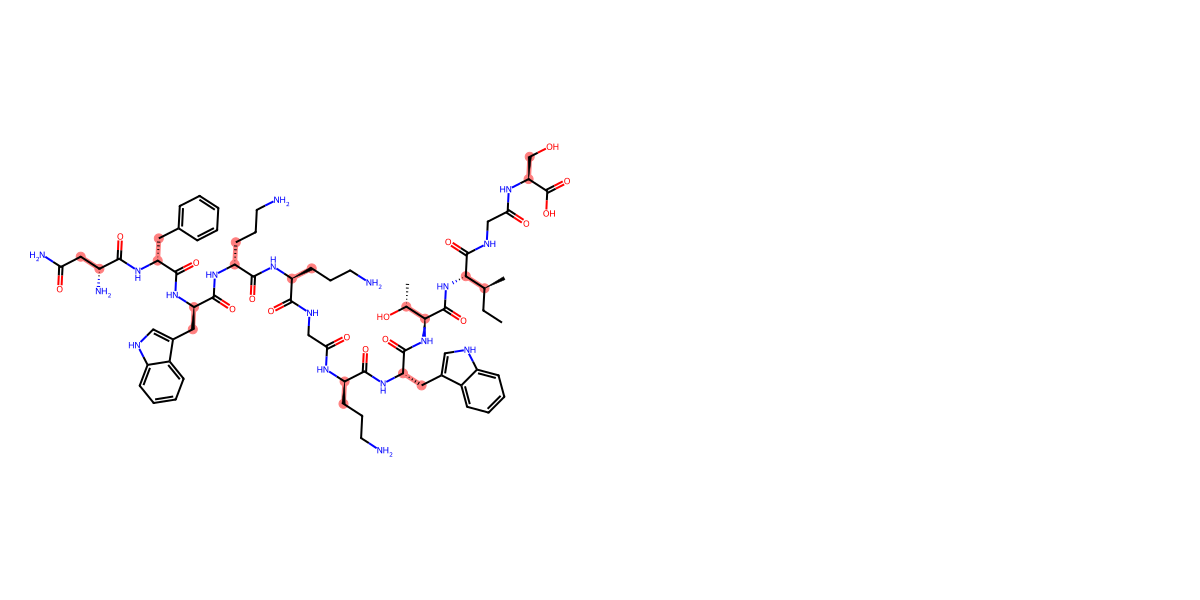

In [11]:
# only keep the first 1 molecule for now
mol_list = mol_list[0:1]

# get bonds to break in each mol
bonds_to_break_list = []
atom_bond_atom_list = []
for mol in mol_list:
    bonds_to_break, atom_bond_atom = get_bond_by_prop(mol)
    print(bonds_to_break, atom_bond_atom)
    bonds_to_break_list.append(bonds_to_break)
    atom_bond_atom = [element for tup in atom_bond_atom for element in tup]
    atom_bond_atom_list.append(atom_bond_atom)
print(bonds_to_break_list)
# visualize the mols with bonds highlighted
Draw.MolsToGridImage(mol_list, molsPerRow=2, subImgSize=(600, 600), highlightAtomLists=atom_bond_atom_list, highlightBondLists=bonds_to_break_list, useSVG=True)

Fragment 0 has 0 dummy atoms
Fragment 1 has 0 dummy atoms
Fragment 2 has 0 dummy atoms
Fragment 3 has 0 dummy atoms
Fragment 4 has 0 dummy atoms
Fragment 5 has 0 dummy atoms
Fragment 6 has 0 dummy atoms
Fragment 7 has 0 dummy atoms
Fragment 8 has 0 dummy atoms
Fragment 9 has 0 dummy atoms
Fragment 10 has 0 dummy atoms
Cannot find backbone. please check inputs


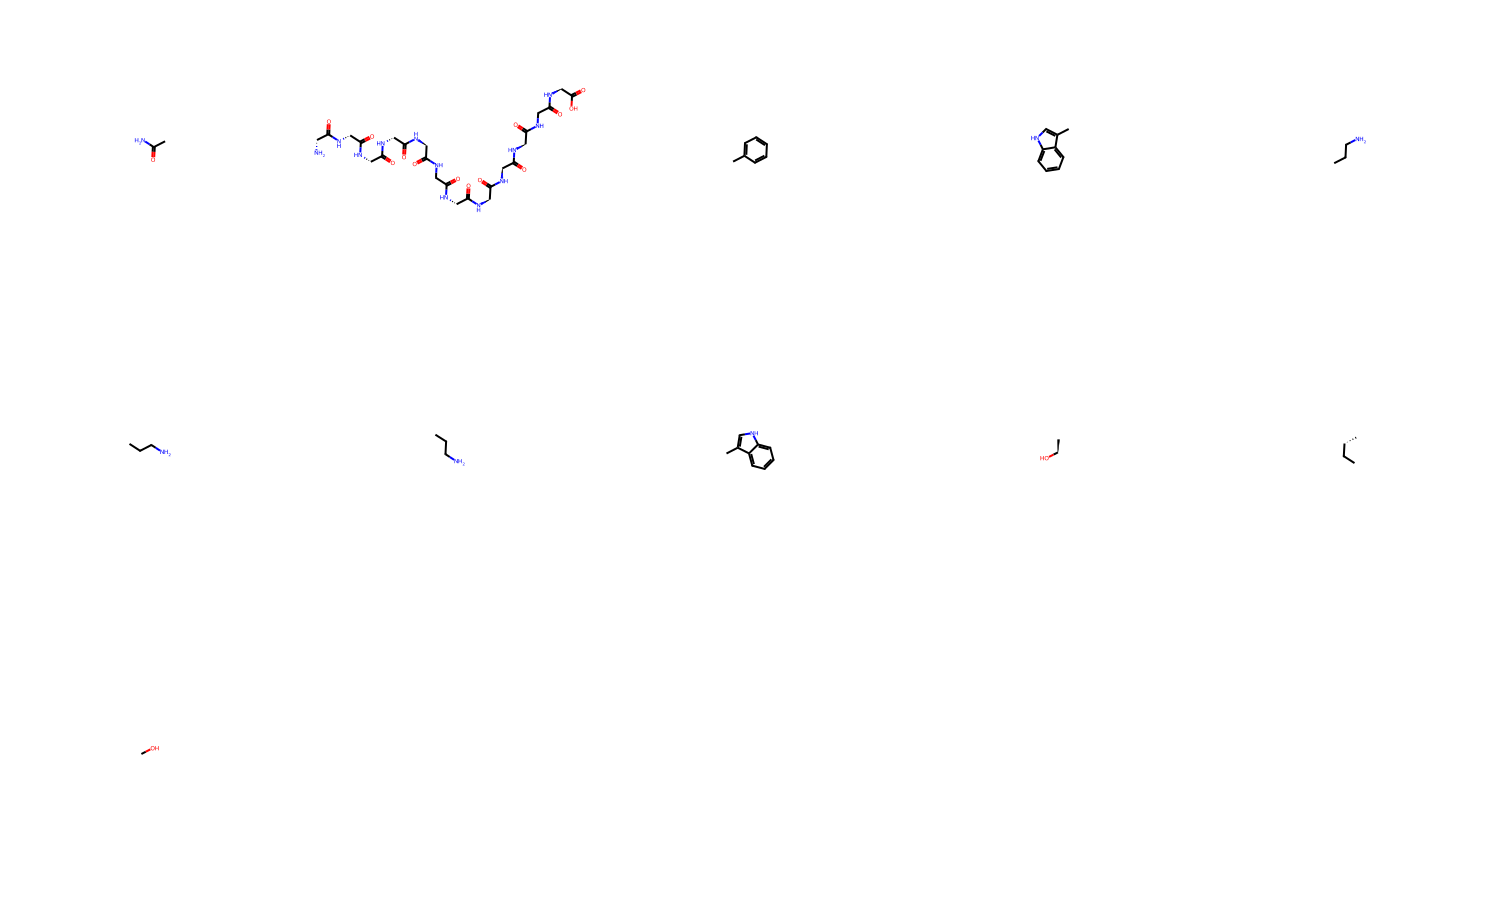

In [12]:
frags_mol_lst = []     # List to store fragments

# Break the bonds by property
for mol, bonds_to_break in zip(mol_list, bonds_to_break_list):
    tmp_mol = Chem.FragmentOnBonds(mol, bonds_to_break, addDummies=False)
    frags_mol_lst.append(Chem.GetMolFrags(tmp_mol, asMols=True))

idx = get_backbone(frags_mol_lst)

# visualize the fragments
Draw.MolsToGridImage([mol for frags in frags_mol_lst for mol in frags], molsPerRow=5, subImgSize=(300, 300), highlightAtomLists=None, highlightBondLists=None, useSVG=True)

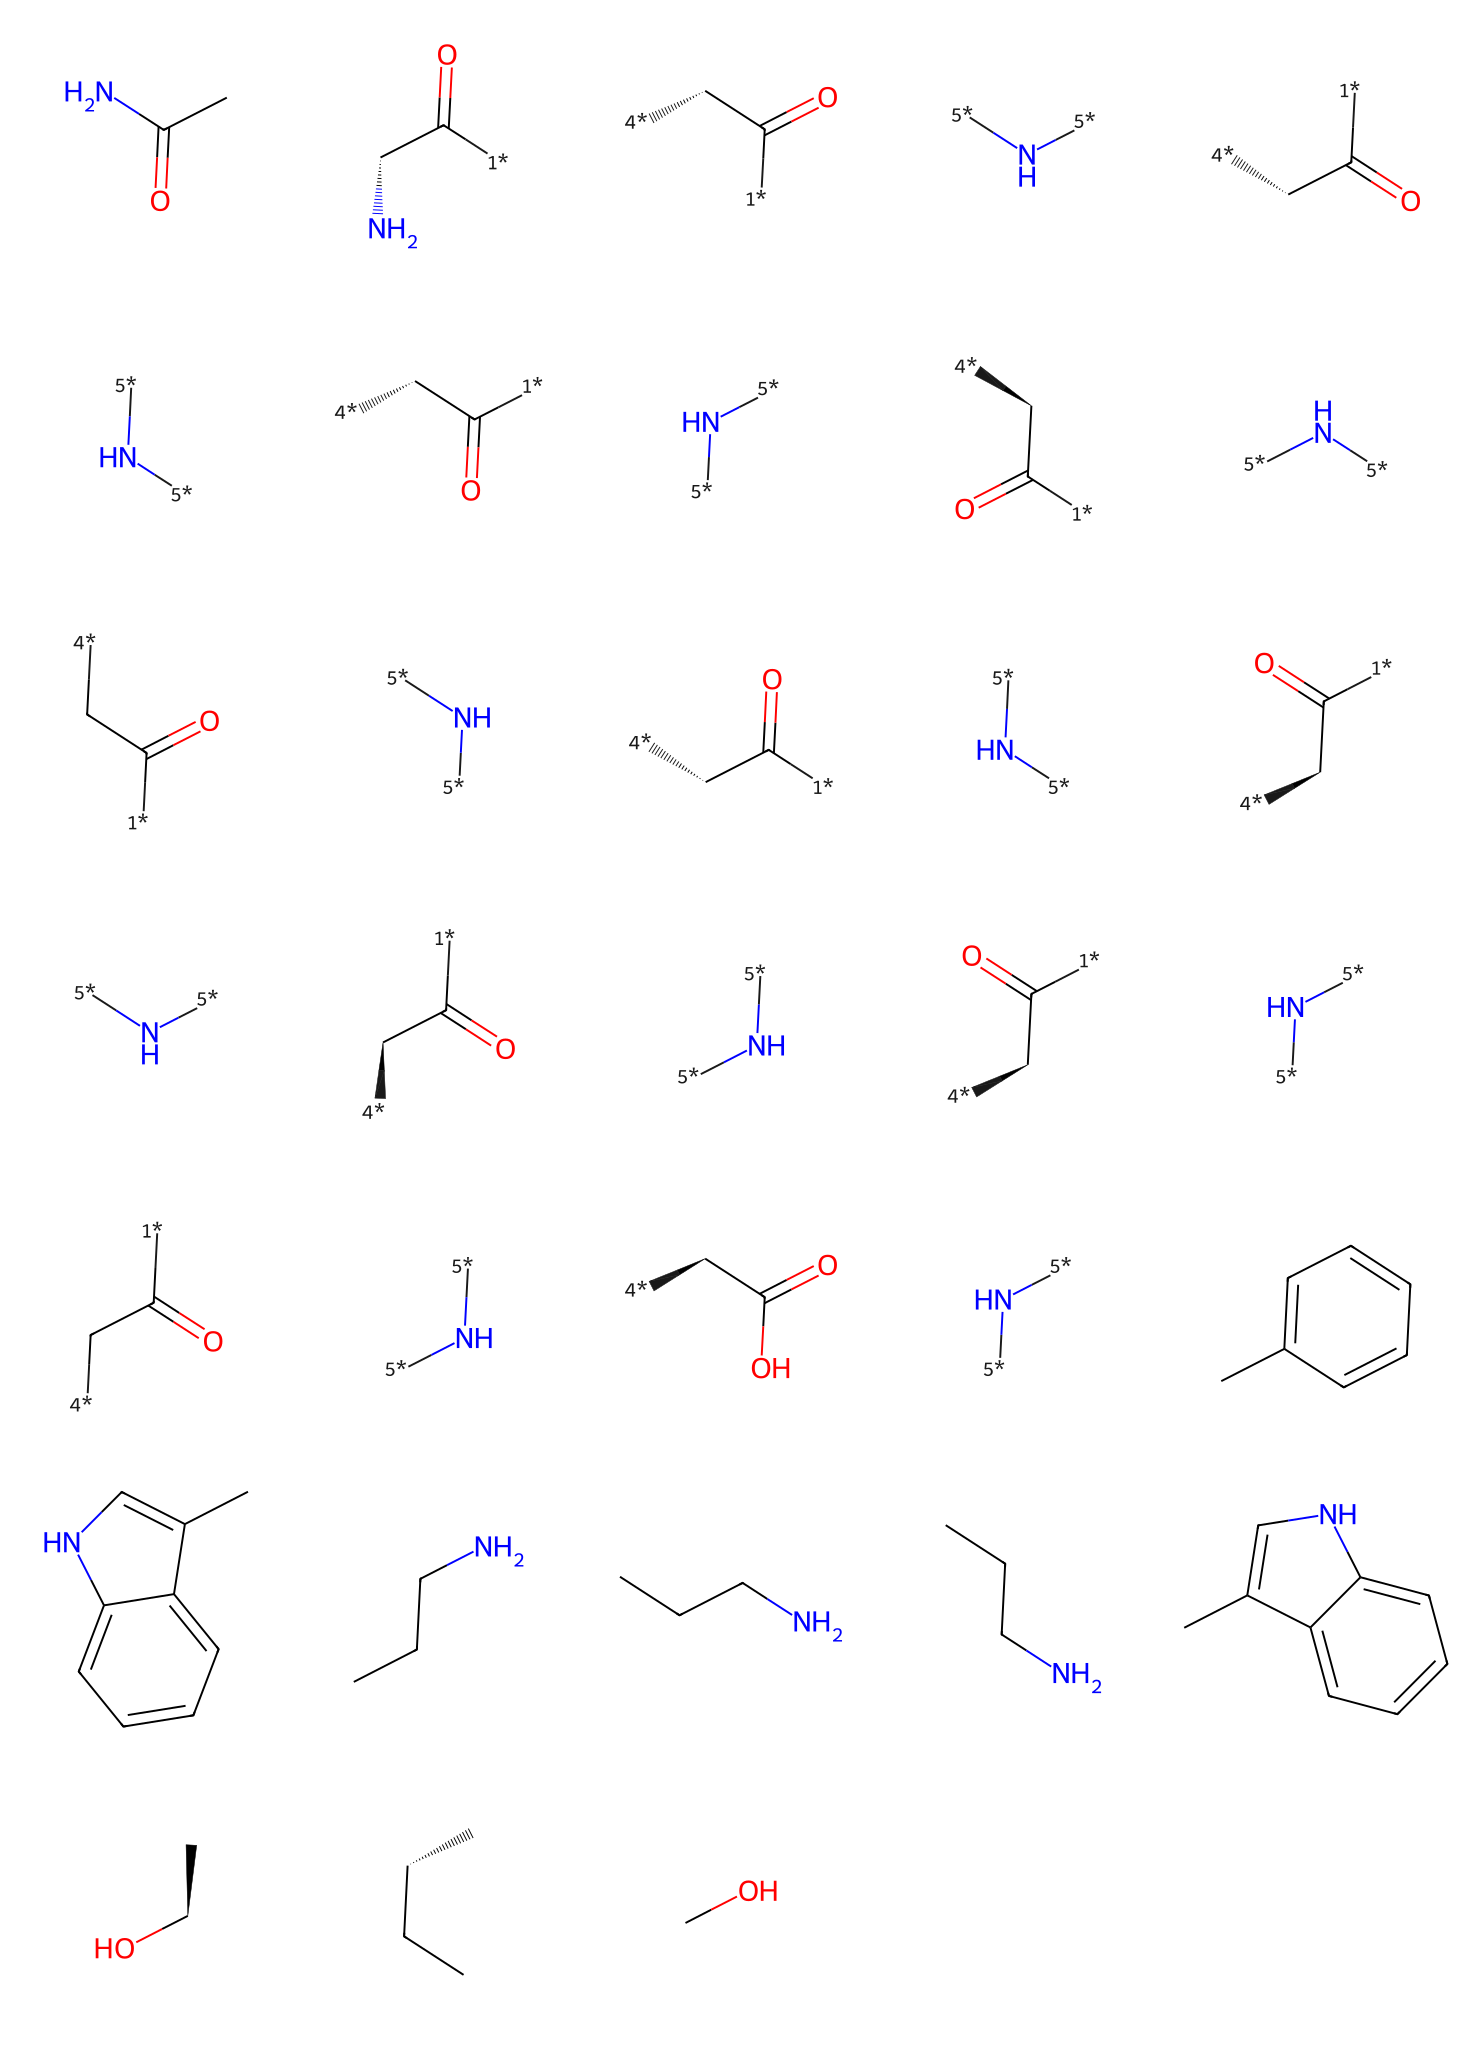

In [13]:
# Break the fragments using BRICS if available, excluding the backbone
for i, frags in enumerate(frags_mol_lst):
    new_frags = []
    for j, frag in enumerate(frags):
        if j == idx:  # Skip the first fragment (backbone)
            new_frags.append(frag)
        else:
            brics_frags = Chem.FragmentOnBRICSBonds(frag)
            new_frags.extend(Chem.GetMolFrags(brics_frags, asMols=True))
    frags_mol_lst[i] = new_frags

Draw.MolsToGridImage([mol for frags in frags_mol_lst for mol in frags], molsPerRow=5, subImgSize=(300, 300), highlightAtomLists=None, highlightBondLists=None, useSVG=True)

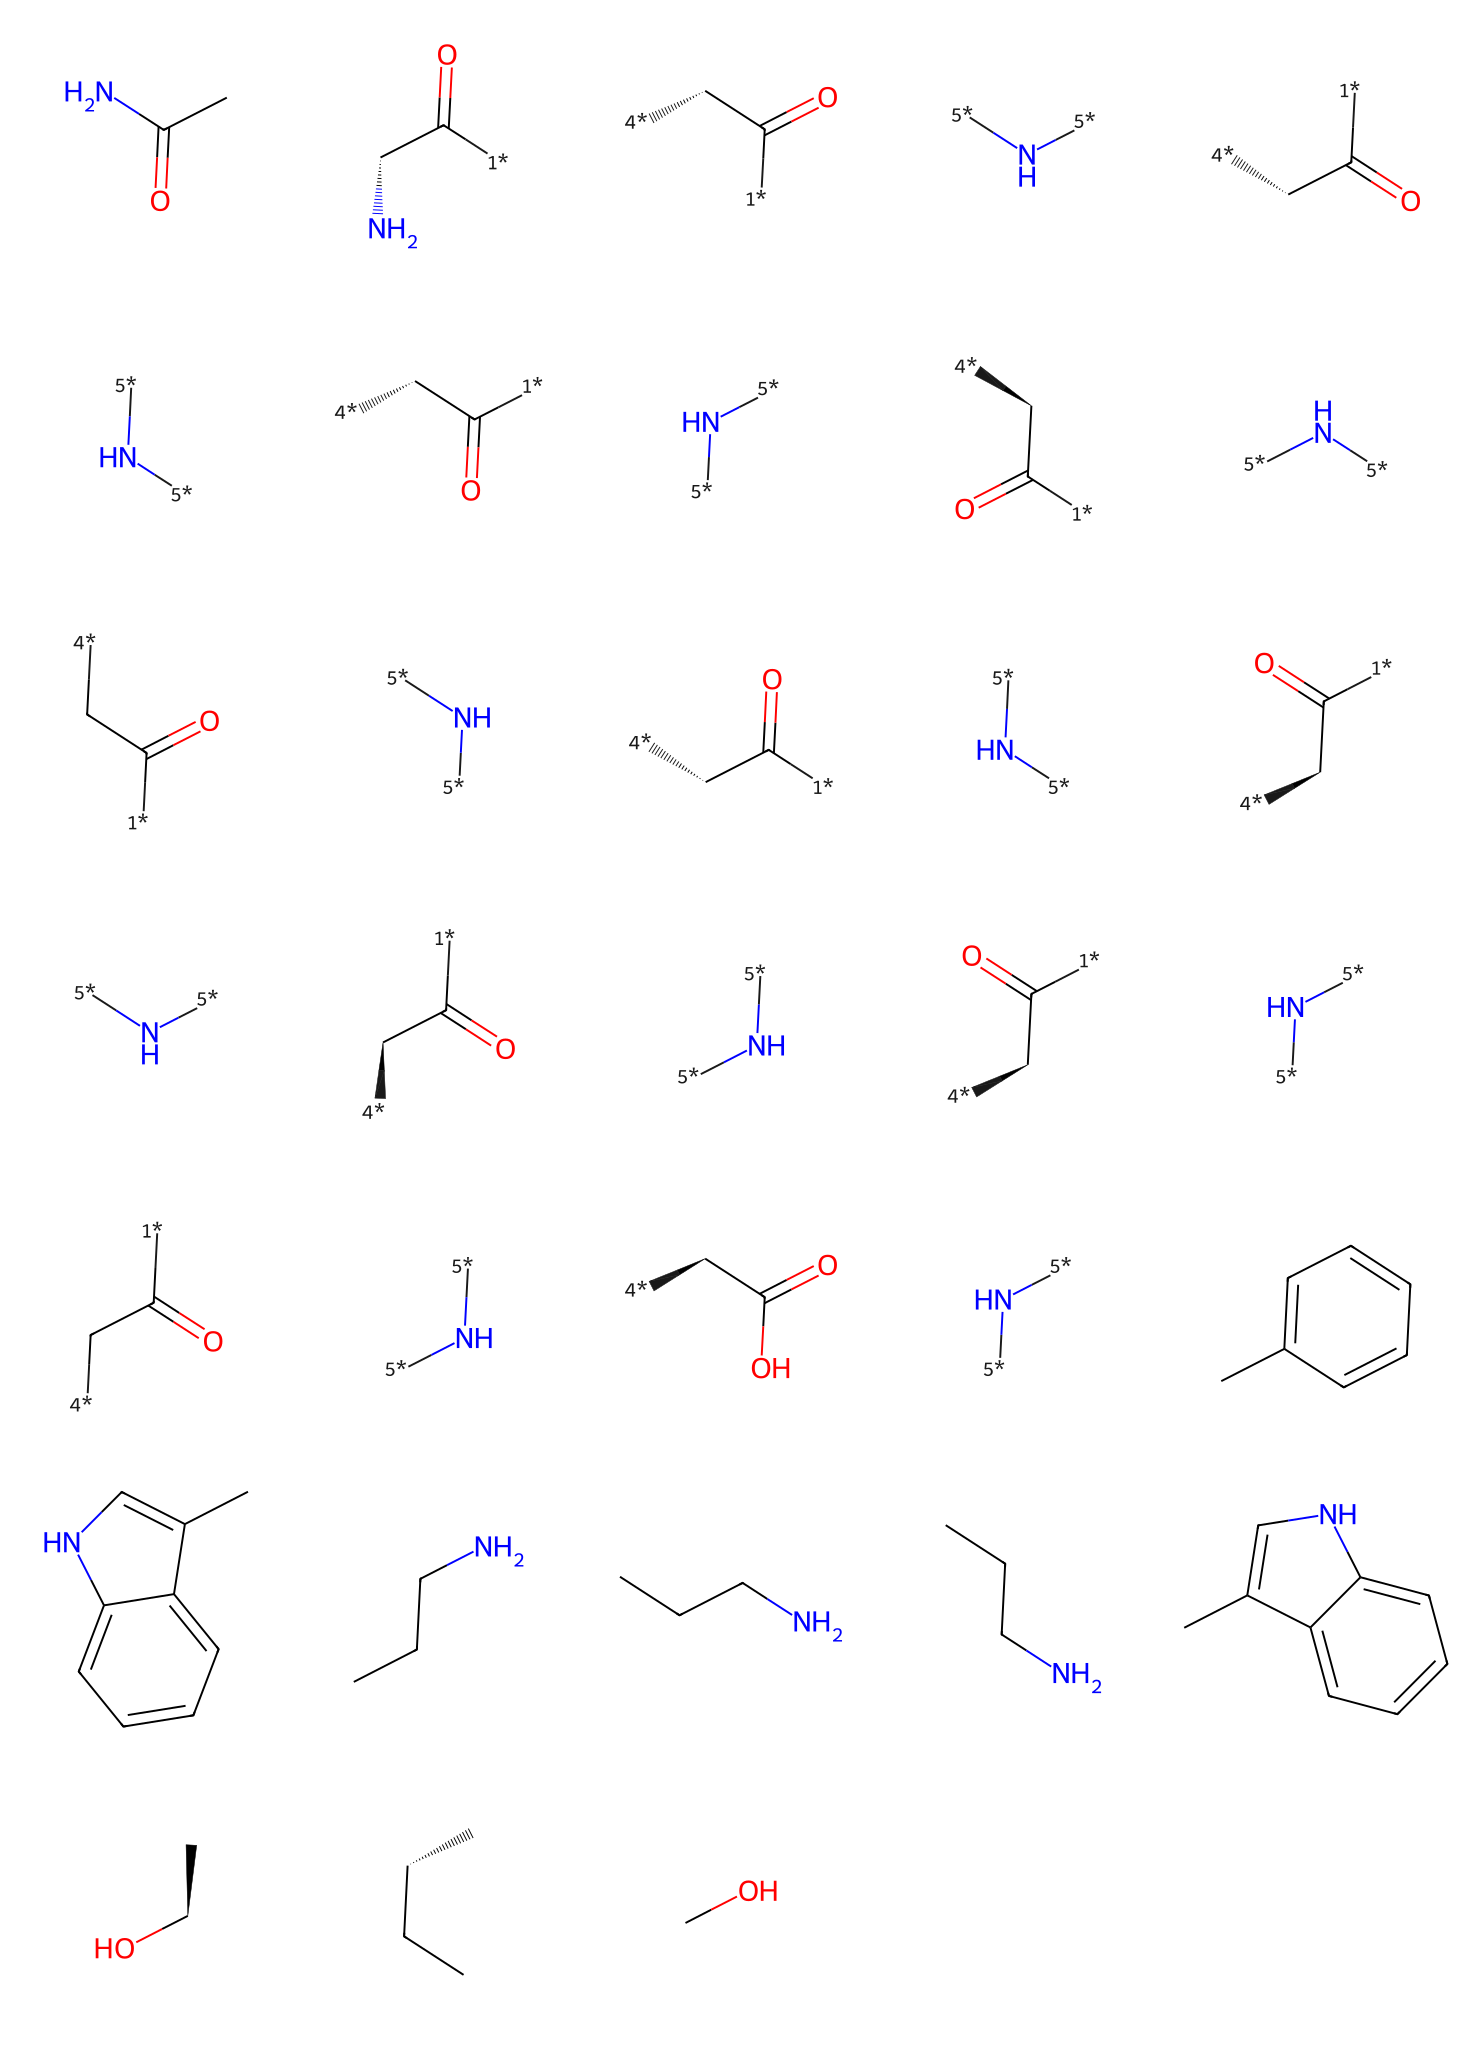

In [14]:
for i, frags in enumerate(frags_mol_lst):
    new_frags = []
    for j, frag in enumerate(frags):
        if j == idx:
            bonds_to_break_bk, atom_bond_atom_bk = get_backbone_cut_idx(frag)
            tmp_mol = Chem.FragmentOnBonds(frag, bonds_to_break_bk, addDummies=False)
            new_frags.extend(Chem.GetMolFrags(tmp_mol, asMols=True))
        else:
            new_frags.append(frag)
    frags_mol_lst[i] = new_frags

Draw.MolsToGridImage([mol for frags in frags_mol_lst for mol in frags], molsPerRow=5, subImgSize=(300, 300), highlightAtomLists=None, highlightBondLists=None, useSVG=True)